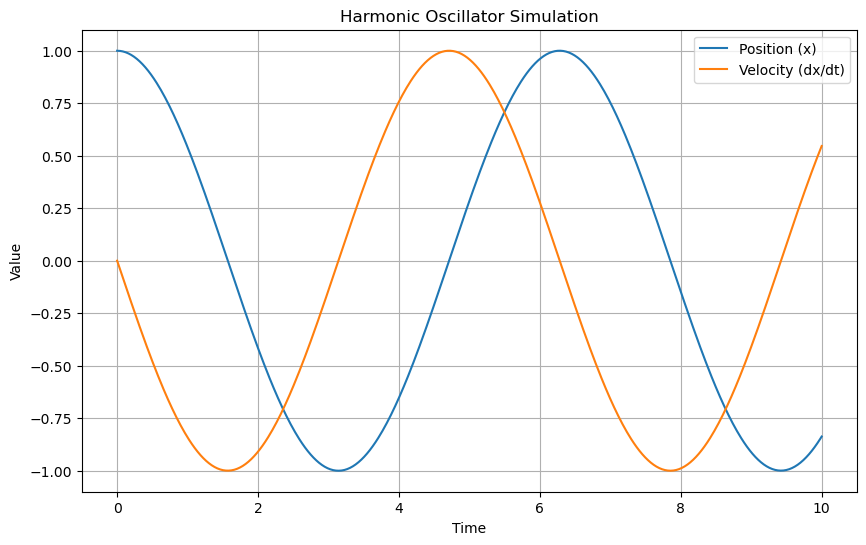

In [1]:
# A test code for simulation code involving time derivatives
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the ODE system (time derivatives)

def harmonic_oscillator(t, y, k, m):
    """
    Defines the system of ODEs for a harmonic oscillator.
    y[0] represents position (x)
    y[1] represents velocity (dx/dt)
    """
    x, v = y
    dxdt = v
    dvdt = -k/m * x  # F = -kx, F = ma => a = -k/m * x
    return [dxdt, dvdt]

# Simulation parameters
k = 1.0  # Spring constant
m = 1.0  # Mass
initial_position = 1.0
initial_velocity = 0.0
t_span = (0, 10)  # Time span for the simulation
t_eval = np.linspace(*t_span, 500) # Points at which to store the solution

# Initial conditions
y0 = [initial_position, initial_velocity]

# Solve the ODE
solution = solve_ivp(
    harmonic_oscillator,
    t_span,
    y0,
    args=(k, m),
    t_eval=t_eval,
    method='RK45' # Runge-Kutta 45 method
)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(solution.t, solution.y[0], label='Position (x)')
plt.plot(solution.t, solution.y[1], label='Velocity (dx/dt)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Harmonic Oscillator Simulation')
plt.legend()
plt.grid(True)
plt.show()

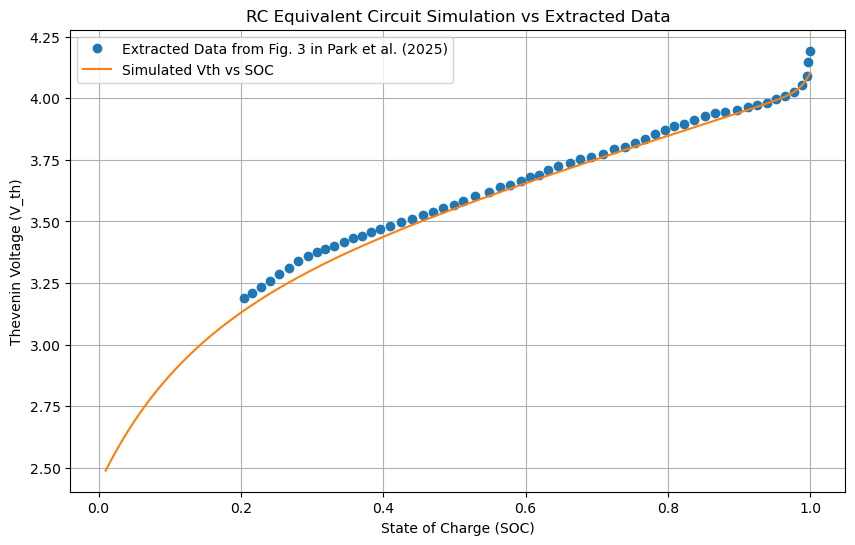

In [ ]:
# A test code for simulation code involving time derivatives
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import os.path
import pandas as pd

## Known Parameters of Battery

C_cap = 3.0   # Battery capacity in Ah
C_th  = 2000  # Equivalent capacity in F, fixed for testing
eta = 0.99   # Coulombic efficiency

# Define the ODE system (time derivatives)

def RC_equivalent_circuit(t, y, I_batt, T_batt):
    """
    Defines the system of ODEs for a RC equivalent circuit
    y[0] represents Voltage thevenin (V)
    y[1] represents State of Charge (SOC)    
    """
    V_th, SOC = y
    R_th = -0.0356 * SOC + 0.0592 # Ohmic resistance as a function of SOC at T_batt=20 oC
    # R_0 = 0.0697 * np.exp(-12.4547 * SOC) + 0.0219 * np.exp(-0.1674 * SOC)  # Ohmic resistance as a function of SOC at T_batt=20 oC
    # V_OC = 3.43 * np.exp(0.1938 * SOC) - 0.5517 * np.exp(-5.0321 * SOC)   # Open circuit voltage as a function of SOC at T_batt=20 oC
    
    dVthdt = -V_th/(R_th*C_th) + I_batt/C_th  # dVth/dt
    dSOCdt = -eta * I_batt/(C_cap*3600)  # dSOC/dt 
    
    return [dVthdt, dSOCdt]

# Simulation parameters
SOC_init = 1.0  # starting State of Charge (fully charged)
Vth_init = 0.0  # initial Thevenin voltage
C_rate = 1.0    # C-rate for discharge
I_batt = C_cap * C_rate  # Constant discharge current in A, equal to 1C rate
T_batt = 20.0   # Battery temperature in Celsius
t_span = (0, 3600)  # Time span for the simulation (1 hour)
t_eval = np.linspace(*t_span, 500) # Points at which to store the solution

# Initial conditions
y0 = [Vth_init, SOC_init]

# Solve the ODE
solution = solve_ivp(
    RC_equivalent_circuit,
    t_span,
    y0,
    args=(I_batt, T_batt),
    t_eval=t_eval,
    method='RK45' # Runge-Kutta 45 method
)

# Calculate terminal voltage over time

## the following correction factors are found in Park's work [[park2025RefinedAircooled]]
alpha = 2.6 * 10**-3 # C-Rate correction factor for R_0 based on C-Rate
beta = - 5.0 * 10**-1  # C-Rate correction factor for R_th based on C-Rate

V_out = []
V_out_corr = []

for i in range(len(solution.t)):
    SOC = solution.y[1][i]
    V_th = solution.y[0][i]
    
    R_th = -0.0356 * SOC + 0.0592 # Ohmic resistance as a function of SOC at T_batt=20 oC
    R_th_corr = R_th * np.exp(beta * C_rate)  # C-Rate correction for R_th, found in Park's work [[park2025RefinedAircooled]]
    
    R_0 = 0.0697 * np.exp(-12.4547 * SOC) + 0.0219 * np.exp(-0.1674 * SOC)  # Ohmic resistance as a function of SOC at T_batt=20 oC
    R_0_corr = R_0 + alpha / C_rate # C-Rate correction for R_0 found in Park's work [[park2025RefinedAircooled]]
    
    V_OC = 3.43 * np.exp(0.1938 * SOC) - 0.5517 * np.exp(-5.0321 * SOC)   # Open circuit voltage as a function of SOC at T_batt=20 oC
    V_out.append(V_OC - I_batt * R_0 - V_th)        


# Read the data saved in datafile
datafile = os.path.join(os.path.curdir, "data", "HP02R0301A2 data_SOC vs Vth_18650-30Q_extracted_Fig_03_park2025RefinedAircooled_xin_20251208.xlsx")

if os.path.isfile(datafile):
    df = pd.read_excel(datafile, sheet_name='1C')
    SOC_data = df['SOC'].to_numpy()[::-1]  # Reverse the SOC data to match discharge direction
    Vth_data = df['Vth'].to_numpy()[::-1]  # Reverse the Vth data to match discharge direction
    
    # Plot the results, Thevenin voltage over SOC
    plt.figure(figsize=(10, 6))
    plt.plot(SOC_data, Vth_data, 'o', label='Extracted Data from Fig. 3 in Park et al. (2025)')
    plt.plot(solution.y[1],V_out, '-', label='Simulated Vth vs SOC')
    plt.xlabel('State of Charge (SOC)')
    plt.ylabel('Thevenin Voltage (V_th)')   
    plt.title('RC Equivalent Circuit Simulation vs Extracted Data')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print(f"Data file {datafile} not found. Skipping data comparison plot.")
    

    # Plot the results, terminal voltage over SOC
        
    plt.figure(figsize=(10, 6))
    plt.plot(solution.y[1], V_out, label='Terminal Voltage (V_out) vs SOC')
    plt.xlabel('State of Charge (SOC)')
    plt.ylabel('Terminal Voltage (V_out)')   
    plt.title('RC Equivalent Circuit Simulation')
    plt.legend()
    plt.grid(True)
    plt.show()